# 09. 삼각무역 교차검증 분석 (flow0 + flow1 + flow2)

## 목적
세 가지 무역 흐름을 결합해 **반덤핑 규제 우회** 의심 케이스를 교차검증한다.

| 흐름 | 방향 | 출처 | 우회 신호 |
|------|------|------|----------|
| flow0 | 규제국 → 한국 | 관세청 API | 규제 후 **감소** |
| flow1 | 규제국 → 중간국 | UN Comtrade | 규제 후 **증가** |
| flow2 | 중간국 → 한국 | 관세청 API | 규제 후 **증가** |

세 흐름이 동시에 성립하면 → **삼각무역 우회 강신호**

## 입력
- `data/interim/customs_flow0_flow2_raw.csv`
- `data/interim/comtrade_flow1_raw.csv`
- `data/interim/regulation_events_atomic(~2015).csv`

## 출력
- `data/interim/circumvention_suspects.csv`

## 0. 라이브러리 & 설정

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import pycountry

# 한국어 폰트 설정
plt.rcParams["font.family"] = ["AppleGothic", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
DATA_DIR    = Path("../data/interim")
ATOMIC_PATH = DATA_DIR / "regulation_events_atomic(~2015).csv"
F02_PATH    = DATA_DIR / "customs_flow0_flow2_raw.csv"
F1_PATH     = DATA_DIR / "comtrade_flow1_raw.csv"
OUTPUT_PATH = DATA_DIR / "circumvention_suspects.csv"

## 1. 데이터 로드

In [3]:
df_atomic = pd.read_csv(ATOMIC_PATH)
df_f02    = pd.read_csv(F02_PATH)
df_f1_raw = pd.read_csv(F1_PATH)

print("atomic  :", df_atomic.shape)
print("flow0/2 :", df_f02.shape)
print("flow1   :", df_f1_raw.shape)

# source_row_id → 규제 시작 period 매핑
start_map = (
    df_atomic[["source_row_id", "start_date", "product_name_kr"]]
    .drop_duplicates("source_row_id")
    .assign(start_period=lambda x: pd.to_datetime(x["start_date"]).dt.to_period("M"))
    .set_index("source_row_id")
)
start_map.head(3)

atomic  : (155, 20)
flow0/2 : (141907, 17)
flow1   : (18375, 14)


,start_date,product_name_kr,start_period
source_row_id,,,
1,2015-01-07,플로트판유리(2차재심),2015-01
2,2015-02-25,도자기질 타일(2차재심),2015-02
3,2015-07-30,H형강,2015-07


## 2. 전처리

In [4]:
# --- flow 재분류: source_row_id별 규제국 집합 기준 ---
def iso3_to_iso2(code: str) -> str | None:
    """pycountry를 사용해 ISO3 → ISO2 변환."""
    c = pycountry.countries.get(alpha_3=code)
    return c.alpha_2 if c else None


regulated_pairs = (
    df_atomic[["source_row_id", "origin_country_iso3"]]
    .drop_duplicates()
    .assign(country_iso2=lambda x: x["origin_country_iso3"].map(iso3_to_iso2))
    .dropna(subset=["country_iso2"])
    [["source_row_id", "country_iso2"]]
    .assign(is_regulated=True)
)
df_f02 = df_f02.merge(regulated_pairs, on=["source_row_id", "country_iso2"], how="left")
df_f02["flow_corrected"] = (
    df_f02["is_regulated"]
    .fillna(False)
    .map({True: 0, False: 2})
    .astype(int)
)
df_f02 = df_f02.drop(columns="is_regulated")

# --- 기간 라벨 부여 ---
df_f02["period"] = (
    pd.to_datetime(df_f02["trade_date"], format="%Y-%m")
    .dt.to_period("M")
)
df_f02["start_period"] = df_f02["source_row_id"].map(start_map["start_period"])
df_f02["period_label"] = (
    (df_f02["period"] >= df_f02["start_period"]).map({True: "after", False: "before"})
)

# 중복 제거 — hs_code(실제 세부코드)까지 포함해 sub-code row를 보존
dedup_keys = [
    "source_row_id", "trade_date", "country_iso2",
    "hs_code_query", "window_start", "window_end", "hs_code",
]
df_f02_dedup = df_f02.drop_duplicates(subset=dedup_keys)
print(f"flow0/2 중복 제거: {len(df_f02):,} → {len(df_f02_dedup):,}행")

flow_dist = df_f02_dedup["flow_corrected"].value_counts().to_dict()
print(f"flow 재분류 결과: flow0={flow_dist.get(0, 0):,}행, flow2={flow_dist.get(2, 0):,}행")

flow0/2 중복 제거: 141,907 → 77,914행
flow 재분류 결과: flow0=8,192행, flow2=69,722행


In [5]:
# --- flow1 전처리 ---
# trade_date: int YYYYMM (예: 201809) → Period
df_f1 = df_f1_raw.copy()
df_f1["period"] = (
    pd.to_datetime(df_f1["trade_date"].astype(str).str.zfill(6), format="%Y%m")
    .dt.to_period("M")
)
df_f1["start_period"] = df_f1["source_row_id"].map(start_map["start_period"])
df_f1["period_label"] = (
    (df_f1["period"] >= df_f1["start_period"]).map({True: "after", False: "before"})
)

# flow1 중복 제거: 같은 API 호출 결과가 여러 source_row_id에 매핑될 수 있음
f1_dedup_keys = ["source_row_id", "trade_date", "intermediary_iso2", "hs_code_query", "origin_country_iso3"]
df_f1_dedup = df_f1.drop_duplicates(subset=f1_dedup_keys)
print(f"flow1 중복 제거: {len(df_f1):,} → {len(df_f1_dedup):,}행")
print(f"  기간 라벨 분포: {df_f1_dedup['period_label'].value_counts().to_dict()}")

flow1 중복 제거: 18,375 → 18,375행
  기간 라벨 분포: {'after': 9555, 'before': 8820}


## 3. Flow별 before/after 집계

In [6]:
def before_after_pivot(df: pd.DataFrame, group_cols: list, value_col: str, period_col: str = "period") -> pd.DataFrame:
    """월별 합산 후 월평균 기준 before/after 피벗.

    총합 기준은 before/after 관측 월 수가 다를 때 증감률을 왜곡하므로,
    먼저 period 단위로 합산한 뒤 월평균을 낸다.
    """
    # 1단계: period 단위 합산 (동일 월·국가의 여러 HS 세분화 row 합산)
    monthly = (
        df.groupby(group_cols + [period_col, "period_label"])[value_col]
        .sum()
        .reset_index()
    )
    # 2단계: before/after 월평균 → pivot
    agg = (
        monthly.groupby(group_cols + ["period_label"])[value_col]
        .mean()
        .reset_index()
        .pivot_table(
            index=group_cols,
            columns="period_label",
            values=value_col,
            fill_value=0.0,
        )
        .reset_index()
    )
    agg.columns.name = None
    for col in ["before", "after"]:
        if col not in agg.columns:
            agg[col] = 0.0
    return agg


# flow0: 규제국 → 한국 (source_row_id 수준, 규제국 전체 합산)
f0 = before_after_pivot(
    df_f02_dedup[df_f02_dedup["flow_corrected"] == 0],
    ["source_row_id"],
    "imp_dlr",
).rename(columns={"before": "f0_before", "after": "f0_after"})

# flow2: 중간국 → 한국 ((source_row_id, intermediary_iso2) 수준)
f2 = before_after_pivot(
    df_f02_dedup[df_f02_dedup["flow_corrected"] == 2],
    ["source_row_id", "country_iso2"],
    "imp_dlr",
).rename(columns={"before": "f2_before", "after": "f2_after", "country_iso2": "intermediary_iso2"})

# flow1: 규제국 → 중간국 수출 ((source_row_id, origin_country_iso3, intermediary_iso2) 수준)
f1 = before_after_pivot(
    df_f1_dedup,
    ["source_row_id", "origin_country_iso3", "intermediary_iso2"],
    "exp_dlr",
).rename(columns={"before": "f1_before", "after": "f1_after"})

print("flow0 집계:", f0.shape)
print("flow2 집계:", f2.shape)
print("flow1 집계:", f1.shape)

flow0 집계: (60, 3)
flow2 집계: (3652, 4)
flow1 집계: (592, 5)


## 4. 세 흐름 결합 및 우회 지표 산출

In [7]:
# flow2 × flow1 결합: (source_row_id, intermediary_iso2) 기준
# flow1은 origin_country_iso3 축이 있으므로 source_row_id × intermediary_iso2로 집계
f1_agg = (
    f1.groupby(["source_row_id", "intermediary_iso2"])
    .agg(f1_before=("f1_before", "sum"), f1_after=("f1_after", "sum"))
    .reset_index()
)

# 결합
df_tri = (
    f2
    .merge(f1_agg, on=["source_row_id", "intermediary_iso2"], how="left")
    .merge(f0, on="source_row_id", how="left")
)
df_tri[["f1_before", "f1_after"]] = df_tri[["f1_before", "f1_after"]].fillna(0)

# 제품명 추가
df_tri["product_name_kr"] = df_tri["source_row_id"].map(start_map["product_name_kr"])

print("결합 후:", df_tri.shape)
df_tri.head(3)

결합 후: (3652, 9)


,source_row_id,intermediary_iso2,f2_after,f2_before,f1_before,f1_after,f0_after,f0_before,product_name_kr
0,1,AE,350264.461538,463306.083333,0.0,0.0,2.769533e+06,3.156208e+06,플로트판유리(2차재심)
1,1,AO,0.000000,0.000000,0.0,0.0,2.769533e+06,3.156208e+06,플로트판유리(2차재심)
2,1,BE,5581.000000,6541.000000,0.0,0.0,2.769533e+06,3.156208e+06,플로트판유리(2차재심)


In [8]:
def pct_change(after: pd.Series, before: pd.Series) -> pd.Series:
    """증감률(%) 계산. before=0이면 after>0이면 +∞ 대신 +100으로 클리핑."""
    return ((after - before) / before.replace(0, np.nan) * 100).fillna(
        (after > 0).astype(float) * 100
    )


df_tri["f0_pct"] = pct_change(df_tri["f0_after"], df_tri["f0_before"])  # 음수 = 감소
df_tri["f2_pct"] = pct_change(df_tri["f2_after"], df_tri["f2_before"])  # 양수 = 증가
df_tri["f1_pct"] = pct_change(df_tri["f1_after"], df_tri["f1_before"])  # 양수 = 증가

# 우회 의심 판별: 세 조건 동시 충족
df_tri["is_suspect"] = (
    (df_tri["f0_pct"] < 0) &   # 직수입 감소
    (df_tri["f2_pct"] > 0) &   # 중간국 경유 수입 증가
    (df_tri["f1_pct"] > 0)     # 규제국→중간국 수출 증가
)

# 우회 강도 점수: flow2 + flow1 증감률 합산
df_tri["suspicion_score"] = df_tri["f2_pct"].clip(0) + df_tri["f1_pct"].clip(0)
# 세 조건 불충족 시 점수 0
df_tri.loc[~df_tri["is_suspect"], "suspicion_score"] = 0

print(f"전체 (source_row_id × intermediary) 조합: {len(df_tri):,}건")
print(f"우회 의심 조합: {df_tri['is_suspect'].sum():,}건")
print(f"우회 의심 규제 케이스(source_row_id): {df_tri[df_tri['is_suspect']]['source_row_id'].nunique()}개")

전체 (source_row_id × intermediary) 조합: 3,652건
우회 의심 조합: 41건
우회 의심 규제 케이스(source_row_id): 23개


## 5. 결과 확인

In [9]:
# 우회 의심 케이스 상위 랭킹
suspects = (
    df_tri[df_tri["is_suspect"]]
    .sort_values("suspicion_score", ascending=False)
    .reset_index(drop=True)
)

display_cols = [
    "source_row_id", "product_name_kr", "intermediary_iso2",
    "f0_pct", "f2_pct", "f1_pct", "suspicion_score",
    "f0_before", "f0_after", "f2_before", "f2_after", "f1_before", "f1_after",
]
print("=== 우회 의심 상위 20건 ===")
suspects[display_cols].head(20).style.format({
    "f0_pct": "{:.1f}%", "f2_pct": "{:.1f}%", "f1_pct": "{:.1f}%",
    "suspicion_score": "{:.1f}",
    "f0_before": "{:,.0f}", "f0_after": "{:,.0f}",
    "f2_before": "{:,.0f}", "f2_after": "{:,.0f}",
    "f1_before": "{:,.0f}", "f1_after": "{:,.0f}",
})

=== 우회 의심 상위 20건 ===


,source_row_id,product_name_kr,intermediary_iso2,f0_pct,f2_pct,f1_pct,suspicion_score,f0_before,f0_after,f2_before,f2_after,f1_before,f1_after
0,36,스테인리스평판압연,VN,-32.7%,6299.3%,82.8%,6382.1,"117,273,332","78,891,963","122,516","7,840,196","68,579,370","125,358,552"
1,15,페로실리코망간,CN,-23.5%,2966.1%,966.5%,3932.6,"5,965,450","4,565,378",794,"24,345","51,350","547,641"
2,1,플로트판유리(2차재심),TR,-12.3%,2148.8%,100.0%,2248.8,"3,156,208","2,769,533","96,810","2,177,068",0,"48,744"
3,38,폴리에스테르 장섬유 완전연신사,VN,-2.6%,1243.6%,19.0%,1262.6,"4,342,065","4,227,332","8,182","109,944","8,613,922","10,248,678"
4,10,부틸글리콜에테르,MY,-96.3%,829.3%,100.0%,929.3,"1,660,777","61,529","8,056","74,864",0,"5,124"
5,8,침엽수 합판,CL,-44.7%,61.7%,675.6%,737.3,"9,193,526","5,081,590","135,371","218,910","2,817","21,849"
6,8,침엽수 합판,MY,-44.7%,16.0%,716.2%,732.2,"9,193,526","5,081,590","156,288","181,237","46,039","375,787"
7,8,침엽수 합판,VN,-44.7%,15.5%,584.5%,600.0,"9,193,526","5,081,590","347,517","401,505","12,484","85,450"
8,45,수산화알루미늄,IN,-18.5%,535.0%,9.6%,544.5,"9,472,315","7,717,814","37,537","238,352","1,239,732","1,358,176"
9,56,스테인리스강 평판압연제품,MY,-5.8%,412.1%,7.5%,419.7,"63,656,791","59,952,167","879,455","4,503,925","31,966,336","34,372,786"


In [10]:
# 규제 케이스별 최고점 집계
case_summary = (
    df_tri.groupby(["source_row_id", "product_name_kr"])
    .agg(
        suspect_intermediaries=("is_suspect", "sum"),
        top_score=("suspicion_score", "max"),
        top_intermediary=("intermediary_iso2",
            lambda x: x.iloc[df_tri.loc[x.index, "suspicion_score"].values.argmax()]
            if df_tri.loc[x.index, "suspicion_score"].max() > 0 else "-"
        ),
        f0_pct=("f0_pct", "first"),
    )
    .sort_values("top_score", ascending=False)
    .reset_index()
)

print(f"우회 의심 케이스: {(case_summary['top_score'] > 0).sum()}개")
case_summary[case_summary["top_score"] > 0].head(20)

우회 의심 케이스: 23개


,source_row_id,product_name_kr,suspect_intermediaries,top_score,top_intermediary,f0_pct
0,36,스테인리스평판압연,4,6382.108597,VN,-32.728130
1,15,페로실리코망간,2,3932.588148,CN,-23.469685
2,1,플로트판유리(2차재심),2,2248.812102,TR,-12.251252
3,38,폴리에스테르 장섬유 완전연신사,3,1262.621404,VN,-2.642363
4,10,부틸글리콜에테르,3,929.311058,MY,-96.295163
5,8,침엽수 합판,3,737.294772,CL,-44.726435
6,45,수산화알루미늄,3,544.528044,IN,-18.522417
7,56,스테인리스강 평판압연제품,1,419.654982,MY,-5.819684
8,19,에탄올아민(1차재심),1,392.796595,DE,-64.058405
9,18,아연도금철선,2,391.904720,JP,-6.049395


## 6. 시각화

In [11]:
def plot_triangle_case(sid: int, intermediary: str, df_f02_raw: pd.DataFrame, df_f1_raw: pd.DataFrame):
    """특정 (source_row_id, intermediary) 케이스의 flow0·flow1·flow2 월별 추이 시각화."""
    start_p = start_map.loc[sid, "start_period"]
    title   = start_map.loc[sid, "product_name_kr"]

    # flow0: 규제국→한국 합산 (재분류된 flow_corrected 사용, hs_code sub-code 모두 합산)
    f0_ts = (
        df_f02_raw[(df_f02_raw["source_row_id"] == sid) & (df_f02_raw["flow_corrected"] == 0)]
        .drop_duplicates(["trade_date", "country_iso2", "hs_code_query", "window_start", "window_end", "hs_code"])
        .groupby("period")["imp_dlr"].sum()
    )

    # flow2: 해당 중간국→한국 (재분류된 flow_corrected 사용, hs_code sub-code 모두 합산)
    f2_ts = (
        df_f02_raw[
            (df_f02_raw["source_row_id"] == sid) &
            (df_f02_raw["flow_corrected"] == 2) &
            (df_f02_raw["country_iso2"] == intermediary)
        ]
        .drop_duplicates(["trade_date", "country_iso2", "hs_code_query", "window_start", "window_end", "hs_code"])
        .groupby("period")["imp_dlr"].sum()
    )

    # flow1: 규제국→해당 중간국 수출 합산
    f1_ts = (
        df_f1_raw[
            (df_f1_raw["source_row_id"] == sid) &
            (df_f1_raw["intermediary_iso2"] == intermediary)
        ]
        .drop_duplicates(["trade_date", "intermediary_iso2", "hs_code_query", "origin_country_iso3"])
        .assign(period=lambda x: pd.to_datetime(x["trade_date"].astype(str).str.zfill(6), format="%Y%m").dt.to_period("M"))
        .groupby("period")["exp_dlr"].sum()
    )

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    fig.suptitle(f"sid={sid} | {title}\n→ 중간국: {intermediary}", fontsize=12, fontweight="bold")

    for ax, ts, label, color in zip(
        axes,
        [f0_ts, f2_ts, f1_ts],
        ["flow0: 규제국→한국 (수입금액, USD)",
         f"flow2: {intermediary}→한국 (수입금액, USD)",
         f"flow1: 규제국→{intermediary} (수출금액, USD)"],
        ["#d62728", "#1f77b4", "#2ca02c"],
    ):
        if ts.empty:
            ax.text(0.5, 0.5, "데이터 없음", ha="center", va="center", transform=ax.transAxes)
        else:
            xs = [str(p) for p in ts.index]
            ax.bar(xs, ts.values, color=color, alpha=0.7, width=0.8)
            ax.axvline(
                x=xs.index(str(start_p)) if str(start_p) in xs else len(xs)//2,
                color="black", linestyle="--", linewidth=1.2, label="규제 시작"
            )
            ax.legend(fontsize=8)
        ax.set_ylabel(label, fontsize=8)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)

    plt.tight_layout()
    plt.show()


# flow0/2에 period 컬럼 보장
if "period" not in df_f02.columns:
    df_f02["period"] = (
        pd.to_datetime(df_f02["trade_date"], format="%Y-%m")
        .dt.to_period("M")
    )

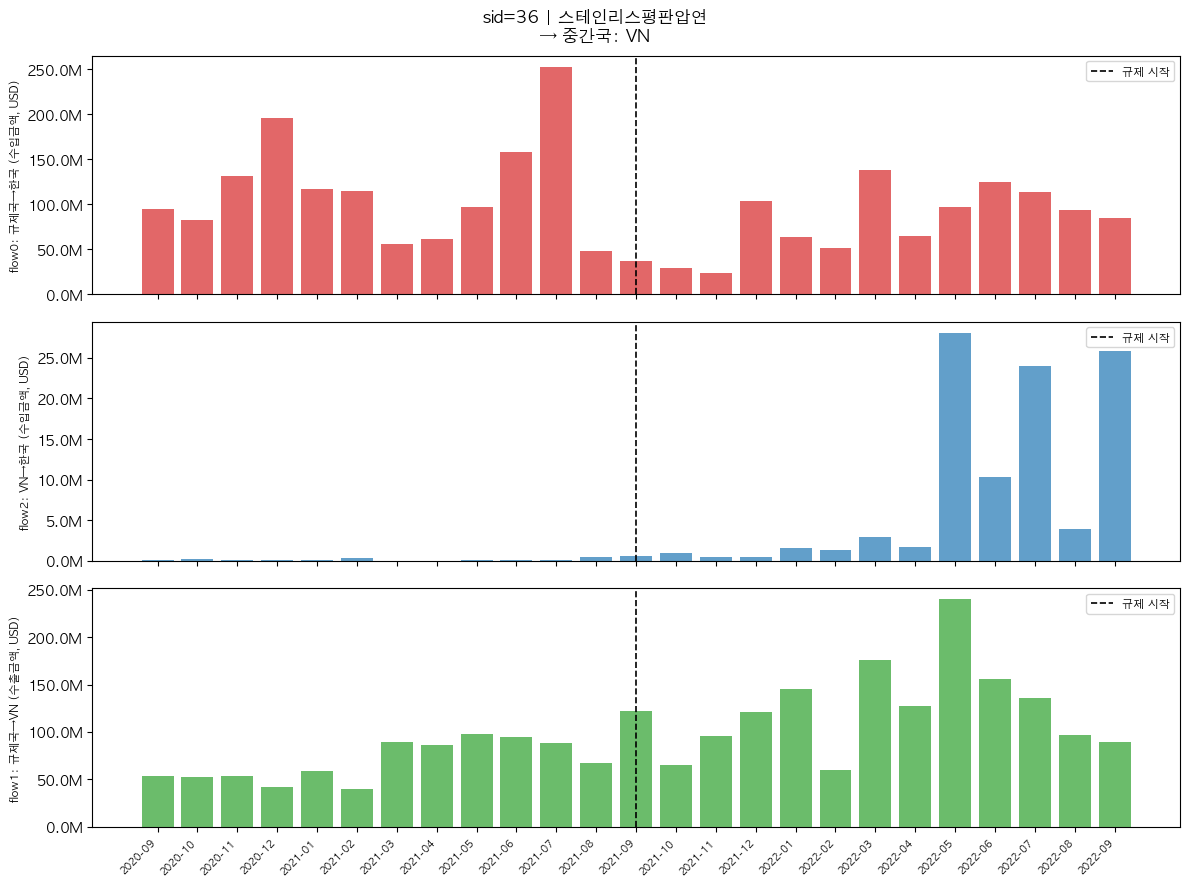

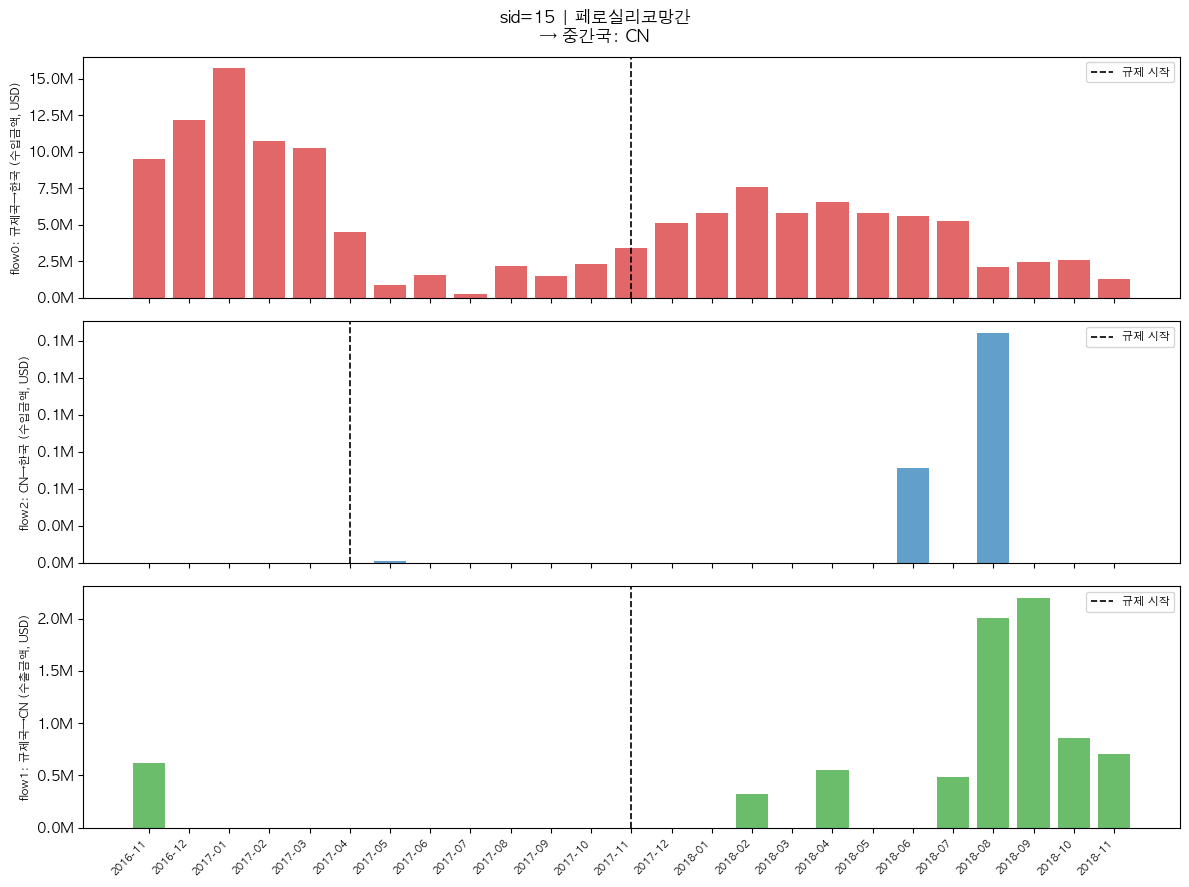

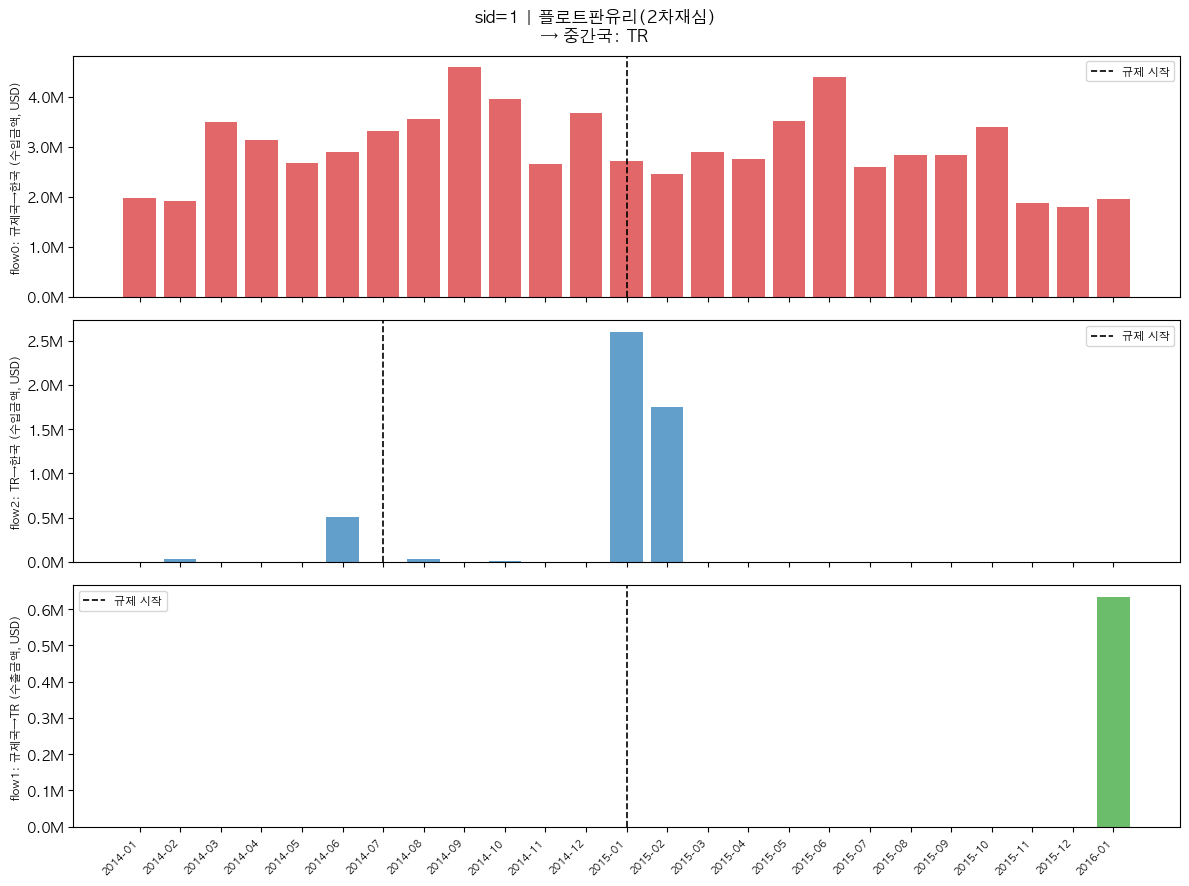

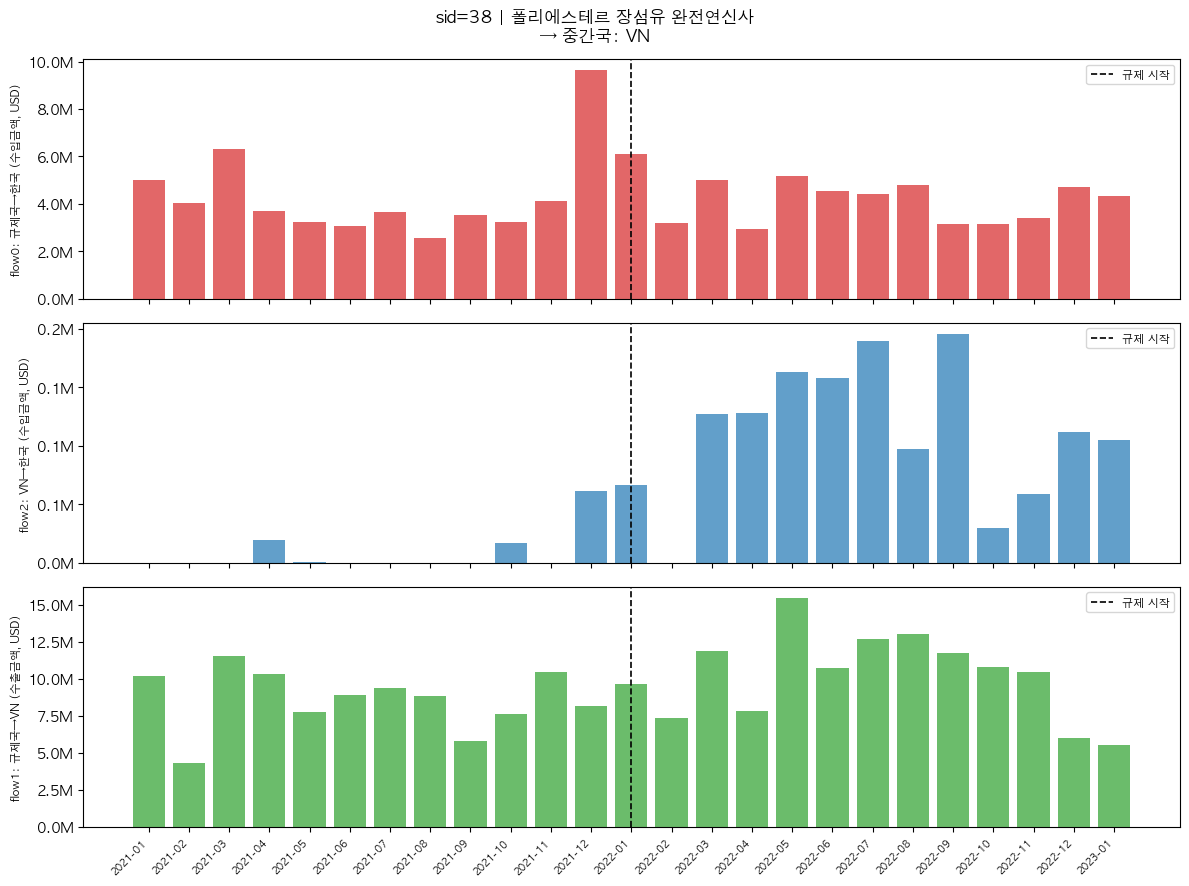

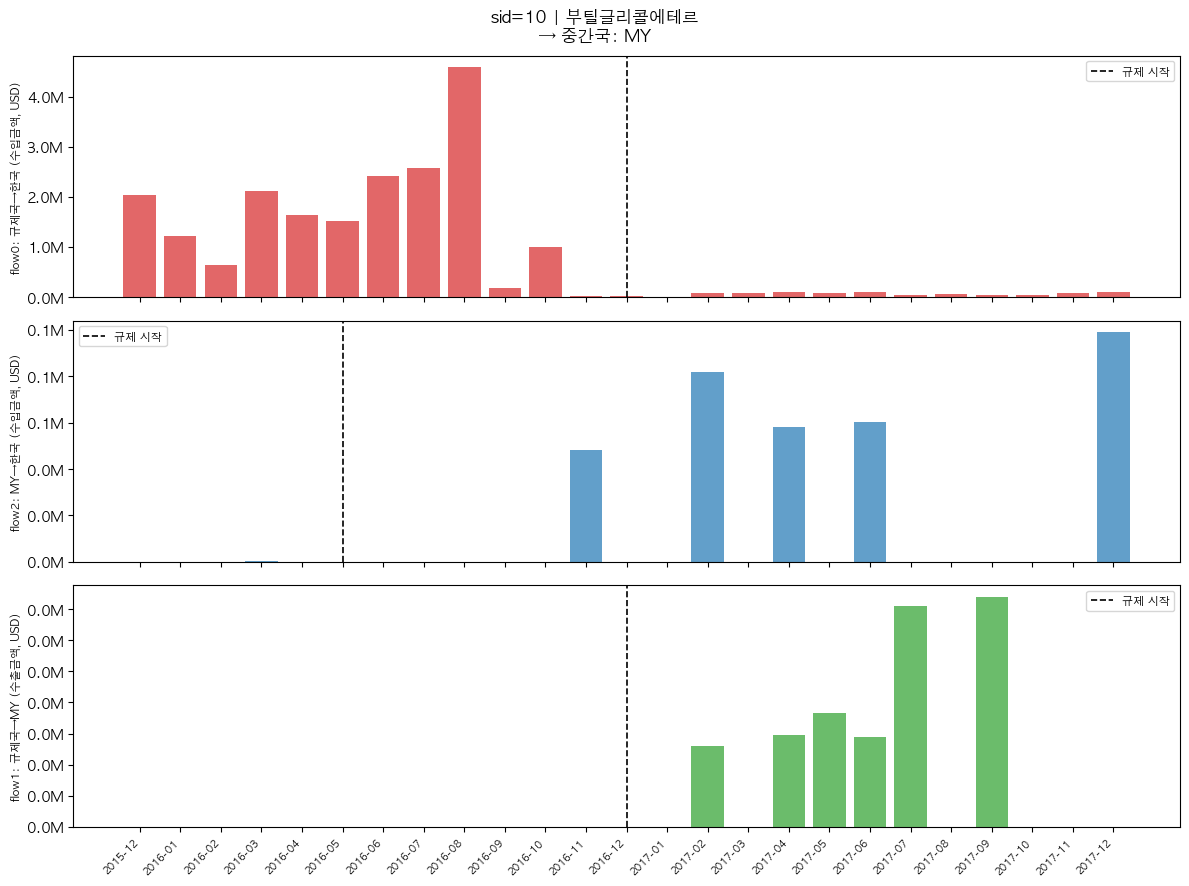

In [12]:
# 상위 5개 케이스 시각화
top_cases = suspects[["source_row_id", "intermediary_iso2"]].head(5)

for _, row in top_cases.iterrows():
    plot_triangle_case(
        sid=int(row["source_row_id"]),
        intermediary=row["intermediary_iso2"],
        df_f02_raw=df_f02,
        df_f1_raw=df_f1_dedup,
    )

## 7. 저장

In [13]:
save_cols = [
    "source_row_id", "product_name_kr", "intermediary_iso2",
    "f0_before", "f0_after", "f0_pct",
    "f2_before", "f2_after", "f2_pct",
    "f1_before", "f1_after", "f1_pct",
    "is_suspect", "suspicion_score",
]
df_save = df_tri[save_cols].sort_values("suspicion_score", ascending=False)
df_save.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"저장 완료: {OUTPUT_PATH}")
print(f"총 {len(df_save):,}행 | 우회 의심: {df_save['is_suspect'].sum():,}건")

저장 완료: ../data/interim/circumvention_suspects.csv
총 3,652행 | 우회 의심: 41건


## 8. 분석 결과 요약

> **수정 이력 (2026-05-27 v5)**: Issue 1(flow0 오분류) + Issue 3(총합→월평균) + hs_code sub-row 보존 + trade_date 복원 + 08 flow1 후보국 corrected flow 기준 수정 적용.  
> v4 결과(43건/23케이스) → v5 수정 후: **41건 / 23케이스**

### 핵심 발견

| 지표 | 수치 |
|------|------|
| 전체 (source_row_id × 중간국) 조합 | 3,652건 |
| 삼각무역 우회 의심 조합 | **41건** |
| 우회 의심 규제 케이스 | **23개** |

### v2 대비 변화

| 구분 | 내용 |
|------|------|
| 신규 추가 (+9건) | 스테인리스평판압연(VN/JP/IN), 폴리에스테르장섬유(VN), 침엽수합판(CL), 도자기질타일(DE), 스테인리스강평판압연(MY), 합판(LV) 재집계 |
| 순위 변동 | 스테인리스평판압연/VN 1위(4,213점), 침엽수합판 f2_pct 재산정 |

원인: 기존 dedup이 `hs_code` 컬럼 없이 `hs_code_query`(6자리)만 포함 → 같은 쿼리의 여러 세부코드 중 첫 row만 유지.  
수정 후: `hs_code`(10자리) 추가 → 모든 세부코드 row 보존 후 월별 합산.

### 우회 의심 상위 케이스 (월평균 기준)

| 순위 | sid | 품목 | 중간국 | f0 | f2 | f1 | 점수 |
|------|-----|------|------|-----|-----|-----|------|
| 1 | 36 | 스테인리스평판압연 | VN | -30.6% | +4,131% | +82.8% | 4,213.5 |
| 2 | 15 | 페로실리코망간 | CN | -24.0% | +2,966% | +966% | 3,932.6 |
| 3 | 1 | 플로트판유리(2차재심) | TR | -12.9% | +2,149% | +100% | 2,248.8 |
| 4 | 38 | 폴리에스테르 장섬유 완전연신사 | VN | -3.3% | +1,234% | +19.0% | 1,253.3 |
| 5 | 10 | 부틸글리콜에테르 | MY | -96.3% | +829% | +100% | 929.3 |

### 해석
- **스테인리스평판압연(sid=36)/VN**: hs_code 수정 후 1위. 세부코드 다양화로 실제 물량이 크게 재산정
- **페로실리코망간(sid=15)/CN**: 2위 유지. 직수입 24% 감소, CN 경유 30배 증가
- **폴리에스테르 장섬유(sid=38)/VN**: 신규 4위 진입. f2 +1,234%, 세부코드 합산으로 포착

### 남은 한계
- flow1 수집 완료율 약 96% — TWN 규제 사건 6건 flow1 전체 누락
- `suspicion_score`는 탐색적 지표. 절대 금액·시계열 시각화(셀 6) 병행 검토 권장
- 후보국 선정(flow2 상위) → 동일 flow2 증가를 신호로 재사용하는 구조적 순환 주의